In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.transforms import v2
import torchvision

In [3]:
# from pathlib import Path
# import shutil
# SOURCE = Path(r"C:\Users\yashs\Downloads\Cheque Verification System\Signature Data\archive (3)\signature_ds_combined")

# DEST = Path("./dataset")
# DEST.mkdir(exist_ok=True)

# for genuine_folder in SOURCE.iterdir():

#     if not genuine_folder.is_dir():
#         continue

#     # Ignore forgery folders
#     if genuine_folder.name.endswith("_forg"):
#         continue

#     person_id = genuine_folder.name

#     forged_folder = SOURCE / f"{person_id}_forg"

#     destination_person = DEST / f"person_{person_id}"

#     genuine_dest = destination_person / "genuine"
#     forged_dest = destination_person / "forged"

#     genuine_dest.mkdir(parents=True, exist_ok=True)
#     forged_dest.mkdir(parents=True, exist_ok=True)

#     # Copy genuine images
#     for img in sorted(genuine_folder.iterdir()):
#         if img.is_file():
#             shutil.copy2(img, genuine_dest / img.name)

#     # Copy forged images
#     if forged_folder.exists():
#         for img in sorted(forged_folder.iterdir()):
#             if img.is_file():
#                 shutil.copy2(img, forged_dest / img.name)

# print("Dataset restructuring complete.")

In [4]:
# from pathlib import Path
# from PIL import Image
# import numpy as np
# import pandas as pd
# from tqdm import tqdm

# DATASET = Path("./dataset")

# stats = []

# widths = []
# heights = []
# category = [".jpg", ".png", ".jpeg"]

# for person in tqdm(sorted(DATASET.iterdir())):

#     genuine = list((person/"genuine").glob("*"))
#     forged = list((person/"forged").glob("*"))

#     stats.append({
#         "writer": person.name,
#         "genuine": len(genuine),
#         "forged": len(forged)
#     })
#     for img_path in genuine + forged:

#         if img_path.suffix not in category:
#             continue

#         img = Image.open(img_path)

#         w, h = img.size

#         widths.append(w)
#         heights.append(h)

# df = pd.DataFrame(stats)

# print(df.head())

# print()

# print("Total writers :", len(df))
# print("Total genuine :", df.genuine.sum())
# print("Total forged  :", df.forged.sum())

# print()

# print("Average width :", np.mean(widths))
# print("Average height:", np.mean(heights))

# print()

# print("Min size :", min(widths), min(heights))
# print("Max size :", max(widths), max(heights))

In [5]:
# from pathlib import Path
# from PIL import Image

# DATASET = Path("./dataset")
# category = [".jpg", ".png", ".jpeg"]

# for person in DATASET.iterdir():

#     for folder in ["genuine", "forged"]:

#         for img_path in (person/folder).glob("*"):
#             if img_path.suffix not in category:
#                 continue
#             img = Image.open(img_path)

#             w,h = img.size

#             if w < 50 or h < 50:

#                 print(img_path, img.size)

In [6]:
# from collections import Counter

# counter = Counter()
# category = [".jpg", ".png", ".jpeg"]

# for person in DATASET.iterdir():

#     for folder in ["genuine","forged"]:

#         for img_path in (person/folder).glob("*"):
#             if img_path.suffix not in category:
#                 continue
#             img = Image.open(img_path)

#             counter[img.mode]+=1

# print(counter)

In [7]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(8,4))
# plt.hist(widths, bins=50)
# plt.title("Image Width Distribution")
# plt.xlabel("Width (pixels)")
# plt.ylabel("Count")
# plt.grid(alpha=0.3)
# plt.show()

# plt.figure(figsize=(8,4))
# plt.hist(heights, bins=50)
# plt.title("Image Height Distribution")
# plt.xlabel("Height (pixels)")
# plt.ylabel("Count")
# plt.grid(alpha=0.3)
# plt.show()

# aspect_ratios = [w / h for w, h in zip(widths, heights)]

# plt.figure(figsize=(8, 4))
# plt.hist(aspect_ratios, bins=50)
# plt.title("Aspect Ratio Distribution")
# plt.xlabel("Width / Height")
# plt.ylabel("Count")
# plt.grid(alpha=0.3)
# plt.show()

In [8]:
# from pathlib import Path
# from PIL import Image

# DATASET = Path("./dataset")

# bad_images = []

# for img_path in DATASET.rglob("*"):

#     if img_path.suffix.lower() not in [".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"]:
#         continue

#     try:
#         Image.open(img_path).verify()

#     except Exception:
#         bad_images.append(img_path)

# print(f"Broken Images : {len(bad_images)}")

# if bad_images:
#     print(*bad_images[:20], sep="\n")

In [2]:
import numpy as np
import torch
from PIL import Image, ImageOps
from torchvision.transforms import v2

IMAGE_SIZE = (448, 224)  # (width, height)

class TightCropToInk:
    def __init__(self, bg_threshold=245, margin=8):
        self.bg_threshold = bg_threshold
        self.margin = margin

    def __call__(self, image):
        image = image.convert("RGB")
        arr = np.array(image)
        gray = arr.mean(axis=2)

        ys, xs = np.where(gray < self.bg_threshold)

        # If nothing meaningful is found, return original
        if len(xs) == 0 or len(ys) == 0:
            return image

        x0 = max(int(xs.min()) - self.margin, 0)
        x1 = min(int(xs.max()) + self.margin + 1, image.width)
        y0 = max(int(ys.min()) - self.margin, 0)
        y1 = min(int(ys.max()) + self.margin + 1, image.height)

        return image.crop((x0, y0, x1, y1))

In [3]:
class LetterboxResize:
    def __init__(self, target_size=(448, 224), fill=(255, 255, 255)):
        self.target_w = target_size[0]
        self.target_h = target_size[1]
        self.fill = fill

    def __call__(self, image):
        image = image.convert("RGB")
        orig_w, orig_h = image.size

        scale = min(self.target_w / orig_w, self.target_h / orig_h)

        new_w = max(1, int(round(orig_w * scale)))
        new_h = max(1, int(round(orig_h * scale)))

        image = image.resize((new_w, new_h), Image.Resampling.LANCZOS)

        pad_left = (self.target_w - new_w) // 2
        pad_right = self.target_w - new_w - pad_left

        pad_top = (self.target_h - new_h) // 2
        pad_bottom = self.target_h - new_h - pad_top

        image = ImageOps.expand(
            image,
            border=(pad_left, pad_top, pad_right, pad_bottom),
            fill=self.fill
        )

        return image

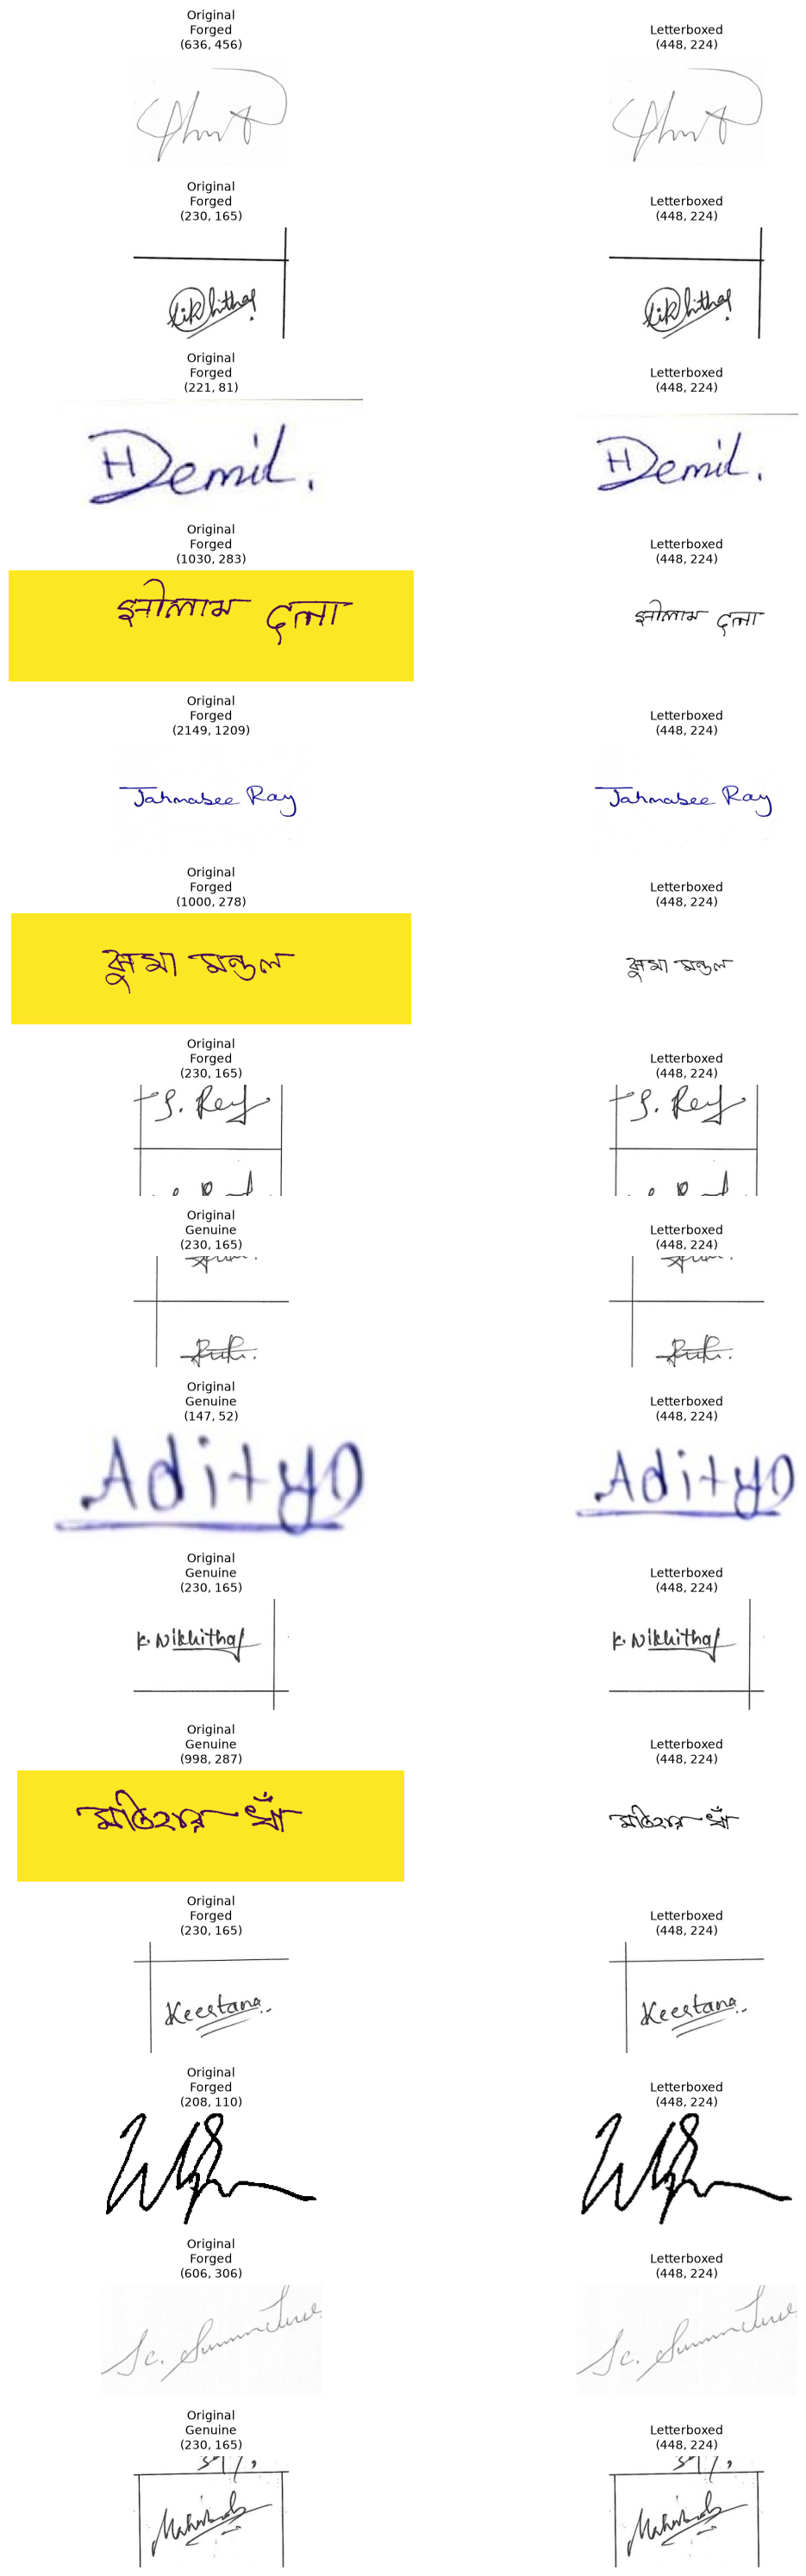

In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import random
DATASET = Path("./dataset")

transform = LetterboxResize(target_size=(448, 224))

all_images = []

for person in DATASET.iterdir():

    genuine_dir = person / "genuine"
    forged_dir = person / "forged"

    for img in genuine_dir.glob("*"):
        all_images.append((img, "Genuine"))

    for img in forged_dir.glob("*"):
        all_images.append((img, "Forged"))

samples = random.sample(all_images, 15)

fig, axes = plt.subplots(15, 2, figsize=(12, 30))

for row, (img_path, label) in enumerate(samples):

    original = Image.open(img_path)

    transformed = transform(original)

    axes[row, 0].imshow(original)
    axes[row, 0].set_title(
        f"Original\n{label}\n{original.size}",
        fontsize=10
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(transformed)
    axes[row, 1].set_title(
        f"Letterboxed\n{transformed.size}",
        fontsize=10
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

In [5]:
from pathlib import Path
from collections import Counter
import json
import random

from sklearn.model_selection import train_test_split


# ============================================================
# CONFIG
# ============================================================

DATASET = Path("./dataset")

IMAGE_EXTS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

RANDOM_STATE = 42

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


# Number of pairs contributed by EACH writer
POSITIVE_PAIRS_PER_WRITER = 20

# Total negative pairs contributed by EACH writer
NEGATIVE_PAIRS_PER_WRITER = 20

# Of the negative pairs, what fraction should be G-F?
FORGED_NEGATIVE_RATIO = 0.70

# Remaining negatives are cross-writer G-G
CROSS_WRITER_NEGATIVE_RATIO = 0.30

In [ ]:
# ============================================================
# DISCOVER WRITERS
# ============================================================

writers = sorted([
    p.name
    for p in DATASET.iterdir()
    if p.is_dir()
])

print(f"Total writers: {len(writers)}")


if len(writers) < 3:
    raise ValueError(
        "At least 3 writers are required for train/val/test."
    )


train_val_writers, test_writers = train_test_split(
    writers,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    shuffle=True
)



val_ratio_of_remaining = (
    VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
)


train_writers, val_writers = train_test_split(
    train_val_writers,
    test_size=val_ratio_of_remaining,
    random_state=RANDOM_STATE,
    shuffle=True
)


train_writers = sorted(train_writers)
val_writers = sorted(val_writers)
test_writers = sorted(test_writers)


print()
print(f"Train writers : {len(train_writers)}")
print(f"Val writers   : {len(val_writers)}")
print(f"Test writers  : {len(test_writers)}")

Total writers: 1487

Train writers : 1040
Val writers   : 223
Test writers  : 224


In [7]:
# WRITER SPLIT SANITY CHECK

train_set = set(train_writers)
val_set = set(val_writers)
test_set = set(test_writers)


assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)


assert (
    len(train_writers)
    + len(val_writers)
    + len(test_writers)
    == len(writers)
)


assert (
    train_set
    | val_set
    | test_set
) == set(writers)


print("\nWriter split verified.")
print("Train ∩ Val  = ∅")
print("Train ∩ Test = ∅")
print("Val   ∩ Test = ∅")


Writer split verified.
Train ∩ Val  = ∅
Train ∩ Test = ∅
Val   ∩ Test = ∅


In [9]:
splits = {
    "train": train_writers,
    "val": val_writers,
    "test": test_writers
}


with open(
    "writer_split.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        splits,
        f,
        indent=4
    )


print("writer_split.json saved.")

writer_split.json saved.


In [10]:
def get_images(directory):

    if not directory.exists():
        return []

    return sorted([
        p
        for p in directory.glob("*")
        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTS
        )
    ])

def build_writer_index(writers):

    index = {}

    for writer in writers:

        writer_dir = DATASET / writer

        genuine = get_images(
            writer_dir / "genuine"
        )

        forged = get_images(
            writer_dir / "forged"
        )

        if len(genuine) < 2:
            raise ValueError(
                f"{writer} has only "
                f"{len(genuine)} genuine images. "
                "Need at least 2."
            )

        index[writer] = {
            "genuine": genuine,
            "forged": forged
        }

    return index

train_index = build_writer_index(train_writers)
val_index = build_writer_index(val_writers)
test_index = build_writer_index(test_writers)

In [15]:
train_index = build_writer_index(train_writers)
val_index = build_writer_index(val_writers)
test_index = build_writer_index(test_writers)

In [12]:
def print_writer_statistics(name, index):

    total_genuine = 0
    total_forged = 0

    print(f"\n{'=' * 60}")
    print(f"{name.upper()} WRITERS")
    print(f"{'=' * 60}")

    for writer, data in index.items():

        genuine_count = len(data["genuine"])
        forged_count = len(data["forged"])

        total_genuine += genuine_count
        total_forged += forged_count

        print(
            f"{writer:20s} "
            f"Genuine: {genuine_count:3d} | "
            f"Forged: {forged_count:3d}"
        )

    print("-" * 60)
    print(f"Writers : {len(index)}")
    print(f"Genuine : {total_genuine}")
    print(f"Forged  : {total_forged}")

print_writer_statistics("train", train_index)
print_writer_statistics("validation", val_index)
print_writer_statistics("test", test_index)


TRAIN WRITERS
person_0001          Genuine:   5 | Forged:   5
person_0002          Genuine:   5 | Forged:   5
person_0003          Genuine:   5 | Forged:   5
person_0004          Genuine:   5 | Forged:   5
person_0005          Genuine:   5 | Forged:   5
person_0006          Genuine:   5 | Forged:   5
person_0007          Genuine:   5 | Forged:   5
person_0008          Genuine:   5 | Forged:   5
person_0009          Genuine:   5 | Forged:   5
person_0011          Genuine:   5 | Forged:   5
person_0012          Genuine:   5 | Forged:   5
person_0013          Genuine:   5 | Forged:   5
person_0014          Genuine:   5 | Forged:   5
person_0017          Genuine:   5 | Forged:   5
person_0018          Genuine:   5 | Forged:   5
person_0019          Genuine:   5 | Forged:   5
person_0020          Genuine:   5 | Forged:   5
person_0021          Genuine:   5 | Forged:   5
person_0022          Genuine:   5 | Forged:   5
person_0023          Genuine:   5 | Forged:   5
person_0025          Genu

In [13]:
print(train_index['person_0001'])

{'genuine': [WindowsPath('dataset/person_0001/genuine/0001_01.jpg'), WindowsPath('dataset/person_0001/genuine/0001_02.jpg'), WindowsPath('dataset/person_0001/genuine/0001_03.jpg'), WindowsPath('dataset/person_0001/genuine/0001_04.jpg'), WindowsPath('dataset/person_0001/genuine/0001_05.jpg')], 'forged': [WindowsPath('dataset/person_0001/forged/0001F_01.jpg'), WindowsPath('dataset/person_0001/forged/0001F_02.jpg'), WindowsPath('dataset/person_0001/forged/0001F_03.jpg'), WindowsPath('dataset/person_0001/forged/0001F_04.jpg'), WindowsPath('dataset/person_0001/forged/0001F_05.jpg')]}


In [14]:
from itertools import combinations


def sample_combinations(
    items,
    n,
    rng
):
    """
    Randomly sample up to n unique unordered pairs.
    """

    if len(items) < 2:
        return []

    all_pairs = list(
        combinations(items, 2)
    )

    if n >= len(all_pairs):
        return all_pairs

    return rng.sample(
        all_pairs,
        n
    )

In [15]:
def build_pairs(
    index,
    positive_pairs_per_writer,
    negative_pairs_per_writer,
    forged_negative_ratio=0.70,
    cross_writer_negative_ratio=0.30,
    seed=42
):

    rng = random.Random(seed)

    writers = sorted(index.keys())

    pairs = []

    # ========================================================
    # DETERMINE NEGATIVE COUNTS
    # ========================================================

    forged_negative_count = int(
        round(
            negative_pairs_per_writer
            * forged_negative_ratio
        )
    )

    cross_writer_negative_count = (
        negative_pairs_per_writer
        - forged_negative_count
    )


    # ========================================================
    # PROCESS EACH WRITER
    # ========================================================

    for writer in writers:

        genuine = index[writer]["genuine"]
        forged = index[writer]["forged"]


        # ====================================================
        # POSITIVE PAIRS
        #
        # G-G from SAME writer
        #
        # LABEL = 0
        # ====================================================

        positive_candidates = list(
            combinations(genuine, 2)
        )

        if len(positive_candidates) == 0:

            raise ValueError(
                f"{writer} does not have enough "
                "genuine signatures."
            )


        positive_count = min(
            positive_pairs_per_writer,
            len(positive_candidates)
        )


        positive_pairs = rng.sample(
            positive_candidates,
            positive_count
        )


        for image_a, image_b in positive_pairs:

            pairs.append({
                "image_a": image_a,
                "image_b": image_b,
                "label": 0,
                "pair_type": "genuine_genuine_same_writer",
                "writer_a": writer,
                "writer_b": writer
            })


        # ====================================================
        # NEGATIVE TYPE 1
        #
        # G-F from SAME writer
        #
        # LABEL = 1
        # ====================================================

        if len(forged) > 0:

            forged_candidates = [
                (genuine_image, forged_image)
                for genuine_image in genuine
                for forged_image in forged
            ]

            forged_count = min(
                forged_negative_count,
                len(forged_candidates)
            )

            selected_forged_pairs = rng.sample(
                forged_candidates,
                forged_count
            )

            for image_a, image_b in selected_forged_pairs:

                pairs.append({
                    "image_a": image_a,
                    "image_b": image_b,
                    "label": 1,
                    "pair_type": "genuine_forged_same_writer",
                    "writer_a": writer,
                    "writer_b": writer
                })

        else:

            forged_count = 0


        # ====================================================
        # NEGATIVE TYPE 2
        #
        # G-G from DIFFERENT writers
        #
        # LABEL = 1
        # ====================================================

        other_writers = [
            other_writer
            for other_writer in writers
            if other_writer != writer
        ]


        if len(other_writers) == 0:

            cross_writer_count = 0

        else:

            for _ in range(
                cross_writer_negative_count
            ):

                other_writer = rng.choice(
                    other_writers
                )

                image_a = rng.choice(
                    genuine
                )

                image_b = rng.choice(
                    index[other_writer]["genuine"]
                )

                pairs.append({
                    "image_a": image_a,
                    "image_b": image_b,
                    "label": 1,
                    "pair_type": "genuine_genuine_different_writer",
                    "writer_a": writer,
                    "writer_b": other_writer
                })

            cross_writer_count = (
                cross_writer_negative_count
            )


    # ========================================================
    # SHUFFLE
    # ========================================================

    rng.shuffle(pairs)

    return pairs

In [16]:
train_pairs = build_pairs(
    index=train_index,
    positive_pairs_per_writer=20,
    negative_pairs_per_writer=20,
    forged_negative_ratio=0.70,
    cross_writer_negative_ratio=0.30,
    seed=42
)


val_pairs = build_pairs(
    index=val_index,
    positive_pairs_per_writer=20,
    negative_pairs_per_writer=20,
    forged_negative_ratio=0.70,
    cross_writer_negative_ratio=0.30,
    seed=43
)


test_pairs = build_pairs(
    index=test_index,
    positive_pairs_per_writer=20,
    negative_pairs_per_writer=20,
    forged_negative_ratio=0.70,
    cross_writer_negative_ratio=0.30,
    seed=44
)

In [17]:
def verify_pair_labels(pairs):

    for pair in pairs:

        writer_a = pair["writer_a"]
        writer_b = pair["writer_b"]

        pair_type = pair["pair_type"]
        label = pair["label"]


        # ----------------------------------------------------
        # SAME-WRITER G-G
        # ----------------------------------------------------

        if pair_type == "genuine_genuine_same_writer":

            assert writer_a == writer_b
            assert label == 0


        # ----------------------------------------------------
        # SAME-WRITER G-F
        # ----------------------------------------------------

        elif pair_type == "genuine_forged_same_writer":

            assert writer_a == writer_b
            assert label == 1


        # ----------------------------------------------------
        # DIFFERENT-WRITER G-G
        # ----------------------------------------------------

        elif pair_type == "genuine_genuine_different_writer":

            assert writer_a != writer_b
            assert label == 1


        else:

            raise ValueError(
                f"Unknown pair type: {pair_type}"
            )


    print(
        f"Verified {len(pairs)} pairs successfully."
    )

verify_pair_labels(train_pairs)
verify_pair_labels(val_pairs)
verify_pair_labels(test_pairs)

Verified 39880 pairs successfully.
Verified 8590 pairs successfully.
Verified 8650 pairs successfully.


In [19]:
def verify_pair_writer_isolation(
    pairs,
    allowed_writers,
    split_name
):

    allowed_writers = set(
        allowed_writers
    )

    for pair in pairs:

        assert pair["writer_a"] in allowed_writers

        assert pair["writer_b"] in allowed_writers


    print(
        f"{split_name}: "
        f"all pairs belong to valid writers."
    )

verify_pair_writer_isolation(
    train_pairs,
    train_writers,
    "TRAIN"
)

verify_pair_writer_isolation(
    val_pairs,
    val_writers,
    "VALIDATION"
)

verify_pair_writer_isolation(
    test_pairs,
    test_writers,
    "TEST"
)

TRAIN: all pairs belong to valid writers.
VALIDATION: all pairs belong to valid writers.
TEST: all pairs belong to valid writers.


In [20]:
def verify_split_isolation():

    train_set = set(train_writers)
    val_set = set(val_writers)
    test_set = set(test_writers)

    assert train_set.isdisjoint(val_set)
    assert train_set.isdisjoint(test_set)
    assert val_set.isdisjoint(test_set)

    print("No writer leakage between splits.")


verify_split_isolation()

No writer leakage between splits.


In [22]:
def print_pair_statistics(name, pairs):

    label_counts = Counter(
        pair["label"]
        for pair in pairs
    )

    type_counts = Counter(
        pair["pair_type"]
        for pair in pairs
    )

    writer_counts = Counter()

    for pair in pairs:

        writer_counts[
            pair["writer_a"]
        ] += 1

        # For cross-writer pairs, writer_b also
        # participates in the pair.
        if (
            pair["pair_type"]
            == "genuine_genuine_different_writer"
        ):
            writer_counts[
                pair["writer_b"]
            ] += 1


    print(f"\n{'=' * 60}")
    print(f"{name.upper()} PAIR STATISTICS")
    print(f"{'=' * 60}")

    print(f"Total pairs : {len(pairs)}")

    print("\nLabels:")
    print(
        f"Label 0 (same genuine): "
        f"{label_counts[0]}"
    )
    print(
        f"Label 1 (different)   : "
        f"{label_counts[1]}"
    )

    print("\nPair types:")

    for pair_type, count in type_counts.items():

        print(
            f"{pair_type}: {count}"
        )
print_pair_statistics(
    "train",
    train_pairs
)

print_pair_statistics(
    "validation",
    val_pairs
)

print_pair_statistics(
    "test",
    test_pairs
)


TRAIN PAIR STATISTICS
Total pairs : 39880

Labels:
Label 0 (same genuine): 19080
Label 1 (different)   : 20800

Pair types:
genuine_genuine_same_writer: 19080
genuine_forged_same_writer: 14560
genuine_genuine_different_writer: 6240

VALIDATION PAIR STATISTICS
Total pairs : 8590

Labels:
Label 0 (same genuine): 4130
Label 1 (different)   : 4460

Pair types:
genuine_genuine_same_writer: 4130
genuine_forged_same_writer: 3122
genuine_genuine_different_writer: 1338

TEST PAIR STATISTICS
Total pairs : 8650

Labels:
Label 0 (same genuine): 4170
Label 1 (different)   : 4480

Pair types:
genuine_genuine_same_writer: 4170
genuine_forged_same_writer: 3136
genuine_genuine_different_writer: 1344


In [23]:
import torch
from torch.utils.data import Dataset
from PIL import Image


class SignaturePairDataset(Dataset):

    def __init__(
        self,
        pairs,
        transform=None
    ):

        self.pairs = pairs
        self.transform = transform


    def __len__(self):

        return len(self.pairs)


    def __getitem__(self, idx):

        pair = self.pairs[idx]

        image_a = Image.open(
            pair["image_a"]
        ).convert("RGB")

        image_b = Image.open(
            pair["image_b"]
        ).convert("RGB")


        if self.transform is not None:

            image_a = self.transform(
                image_a
            )

            image_b = self.transform(
                image_b
            )


        label = torch.tensor(
            pair["label"],
            dtype=torch.float32
        )


        return (
            image_a,
            image_b,
            label
        )

In [24]:
import numpy as np
import torch

from PIL import Image, ImageOps
from torchvision.transforms import v2


IMAGE_SIZE = (448, 224)


class TightCropToInk:

    def __init__(
        self,
        bg_threshold=245,
        margin=8
    ):

        self.bg_threshold = bg_threshold
        self.margin = margin


    def __call__(self, image):

        image = image.convert("RGB")

        arr = np.array(image)

        gray = arr.mean(axis=2)

        ys, xs = np.where(
            gray < self.bg_threshold
        )


        if len(xs) == 0 or len(ys) == 0:

            return image


        x0 = max(
            int(xs.min()) - self.margin,
            0
        )

        x1 = min(
            int(xs.max()) + self.margin + 1,
            image.width
        )

        y0 = max(
            int(ys.min()) - self.margin,
            0
        )

        y1 = min(
            int(ys.max()) + self.margin + 1,
            image.height
        )


        return image.crop(
            (x0, y0, x1, y1)
        )


class LetterboxResize:

    def __init__(
        self,
        target_size=(448, 224),
        fill=(255, 255, 255)
    ):

        self.target_w = target_size[0]
        self.target_h = target_size[1]
        self.fill = fill


    def __call__(self, image):

        image = image.convert("RGB")

        orig_w, orig_h = image.size


        scale = min(
            self.target_w / orig_w,
            self.target_h / orig_h
        )


        new_w = max(
            1,
            int(round(orig_w * scale))
        )

        new_h = max(
            1,
            int(round(orig_h * scale))
        )


        image = image.resize(
            (new_w, new_h),
            Image.Resampling.LANCZOS
        )


        pad_left = (
            self.target_w - new_w
        ) // 2

        pad_right = (
            self.target_w
            - new_w
            - pad_left
        )

        pad_top = (
            self.target_h - new_h
        ) // 2

        pad_bottom = (
            self.target_h
            - new_h
            - pad_top
        )


        image = ImageOps.expand(
            image,
            border=(
                pad_left,
                pad_top,
                pad_right,
                pad_bottom
            ),
            fill=self.fill
        )


        return image

In [25]:
IMAGENET_MEAN = (
    0.485,
    0.456,
    0.406
)

IMAGENET_STD = (
    0.229,
    0.224,
    0.225
)


train_transform = v2.Compose([

    TightCropToInk(
        bg_threshold=245,
        margin=8
    ),

    v2.RandomApply(
        [
            v2.RandomRotation(
                degrees=5,
                fill=(255, 255, 255)
            )
        ],
        p=0.5
    ),

    v2.RandomApply(
        [
            v2.RandomAffine(
                degrees=0,
                translate=(0.02, 0.02),
                scale=(0.95, 1.05),
                shear=3,
                fill=(255, 255, 255)
            )
        ],
        p=0.5
    ),

    LetterboxResize(
        target_size=IMAGE_SIZE,
        fill=(255, 255, 255)
    ),

    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


eval_transform = v2.Compose([

    TightCropToInk(
        bg_threshold=245,
        margin=8
    ),

    LetterboxResize(
        target_size=IMAGE_SIZE,
        fill=(255, 255, 255)
    ),

    v2.ToImage(),

    v2.ToDtype(
        torch.float32,
        scale=True
    ),

    v2.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [26]:
train_dataset = SignaturePairDataset(
    train_pairs,
    transform=train_transform
)

val_dataset = SignaturePairDataset(
    val_pairs,
    transform=eval_transform
)

test_dataset = SignaturePairDataset(
    test_pairs,
    transform=eval_transform
)

In [27]:
from torch.utils.data import DataLoader


BATCH_SIZE = 32

PIN_MEMORY = torch.cuda.is_available()


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

In [28]:
import torch.nn as nn
import torch.nn.functional as F


class ContrastiveLoss(nn.Module):

    def __init__(self, margin=1.0):

        super().__init__()

        self.margin = margin


    def forward(
        self,
        embedding_a,
        embedding_b,
        label
    ):

        distance = F.pairwise_distance(
            embedding_a,
            embedding_b
        )


        # ----------------------------------------------------
        # label = 0
        # Same / similar
        #
        # Minimize distance
        # ----------------------------------------------------

        positive_loss = (
            (1 - label)
            * distance.pow(2)
        )


        # ----------------------------------------------------
        # label = 1
        # Different / dissimilar
        #
        # Push distance beyond margin
        # ----------------------------------------------------

        negative_loss = (
            label
            * torch.clamp(
                self.margin - distance,
                min=0.0
            ).pow(2)
        )


        loss = (
            positive_loss
            + negative_loss
        )


        return loss.mean()

In [29]:
def serialize_pairs(pairs):

    return [
        {
            "image_a": str(pair["image_a"]),
            "image_b": str(pair["image_b"]),
            "label": pair["label"],
            "pair_type": pair["pair_type"],
            "writer_a": pair["writer_a"],
            "writer_b": pair["writer_b"]
        }
        for pair in pairs
    ]

with open(
    "train_pairs.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        serialize_pairs(train_pairs),
        f,
        indent=4
    )


with open(
    "val_pairs.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        serialize_pairs(val_pairs),
        f,
        indent=4
    )


with open(
    "test_pairs.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        serialize_pairs(test_pairs),
        f,
        indent=4
    )

In [18]:
## Loading the Model

import torch
import torch.nn as nn
from torchvision import models

NUM_CLASSES = len(train_writers)

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(in_features, 1024),
    nn.ReLU(inplace=True),
    nn.Dropout(0.3),
    nn.Linear(1024, NUM_CLASSES)
)

In [29]:
print(in_features)

2048


In [19]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

Trainable Parameters : 3,164,176
Total Parameters     : 26,672,208
